# Import packages

In [32]:
import pandas as pd
from seaborn import lineplot
%load_ext autoreload
%autoreload 2
%reload_ext autoreload
from visualisierungen import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Read csv

In [33]:
df = pd.read_csv("../data/processed/df_with_positions.csv")
print(df.head())

   anr       datum  legisjahr             rechtsform_name  \
0  1.0  1848-09-12  1848-1851  Obligatorisches Referendum   
1  2.0  1866-01-14  1863-1866  Obligatorisches Referendum   
2  3.0  1866-01-14  1863-1866  Obligatorisches Referendum   
3  4.0  1866-01-14  1863-1866  Obligatorisches Referendum   
4  5.0  1866-01-14  1863-1866  Obligatorisches Referendum   

                                        titel_kurz_d  anzahl  beteiligung  \
0  Bundesverfassung der schweizerischen Eidgenoss...       1          NaN   
1                                   Mass und Gewicht       9          NaN   
2  Gleichstellung der Juden und Naturalisierten m...       9          NaN   
3  Stimmrecht der Niedergelassenen in Gemeindeang...       9          NaN   
4  Besteuerung und zivilrechtliche Verhältnisse d...       9          NaN   

   annahme  volkja-proz  berecht  ...  zustimmung_p-kdk  zustimmung_p-kkjpd  \
0      1.0        72.83      NaN  ...               NaN                 NaN   
1      0.0  

## Datatype Adaption for this particular analysis

In [34]:
df["jahrzehnt"] = df["jahrzehnt"].astype(str)

institutionen = {
    'Parteien': ['zustimmung_p-svp', 'zustimmung_p-fdp', 'zustimmung_p-mitte',
                 'zustimmung_p-sps', 'zustimmung_p-gps', 'zustimmung_p-glp'],
    'Bundesrat': ['zustimmung_br-pos'],
    'Bundesversammlung': ['zustimmung_bv-pos']}

# Allgemeine zeitliche Analyse

### Balkendiagramm: Anzahl Abstimmungen über Zeit

/Users/charlotteschwegler/Desktop/Repos/Demokratie Challenge/notebooks/visualisierungen.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x=x, y=y, hue=hue,
/Users/charlotteschwegler/Desktop/Repos/Demokratie Challenge/notebooks/visualisierungen.py:63: UserWarning: 
The palette list has fewer values (1) than needed (18) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(data=data, x=x, y=y, hue=hue,


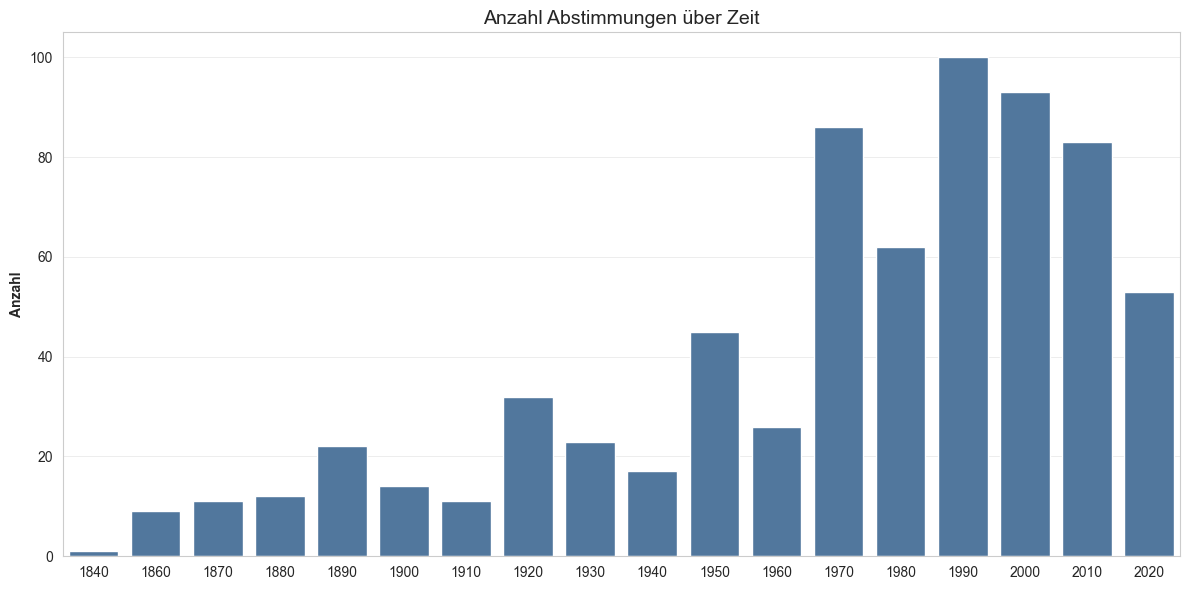

In [35]:
numbers_vote = df.groupby(['jahrzehnt']).size().reset_index(name='anzahl')
balkendiagramm(numbers_vote, x='jahrzehnt', y='anzahl', xlabel="", ylabel="Anzahl", titel="Anzahl Abstimmungen über Zeit",
                  ylim=None, palette= [HAUPTFARBE], figsize=(12,6),
                  rotation=0, order=None, annotate=False, fmt=".0f")

### Balkendiagramm (Anteil): Wer gab Abstimmungsempfehlungen wann?

In [36]:
frames = []
for gruppe, cols in institutionen.items():
    empfehlungen = df.groupby('jahrzehnt')[cols].count().sum(axis=1)
    gesamt = df.groupby('jahrzehnt').size()
    max_empfehlungen = gesamt * len(cols)  # maximal mögliche Empfehlungen
    temp = (empfehlungen / max_empfehlungen).reset_index(name='anteil')
    temp['gruppe'] = gruppe
    frames.append(temp)

numbers_vote = pd.concat(frames, ignore_index=True)

/Users/charlotteschwegler/Desktop/Repos/Demokratie Challenge/notebooks/visualisierungen.py:63: UserWarning: The palette list has more values (6) than needed (3), which may not be intended.
  sns.barplot(data=data, x=x, y=y, hue=hue,


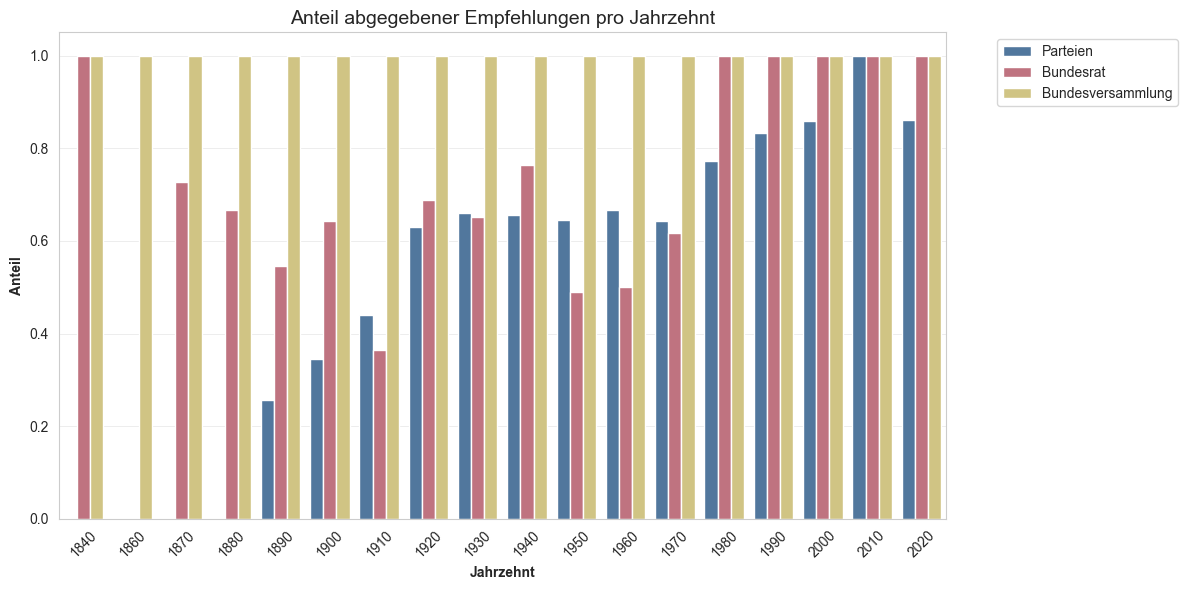

In [37]:
balkendiagramm(numbers_vote, x='jahrzehnt', y='anteil', hue='gruppe',
               titel="Anteil abgegebener Empfehlungen pro Jahrzehnt",
               xlabel="Jahrzehnt", ylabel="Anteil",
               figsize=(12, 6), rotation=45)

# Zeitliche Entwicklung

## Postion Insitution vs. Position Bevölkerung

### Liniendiagramme

#### Liniendiagramm: BR

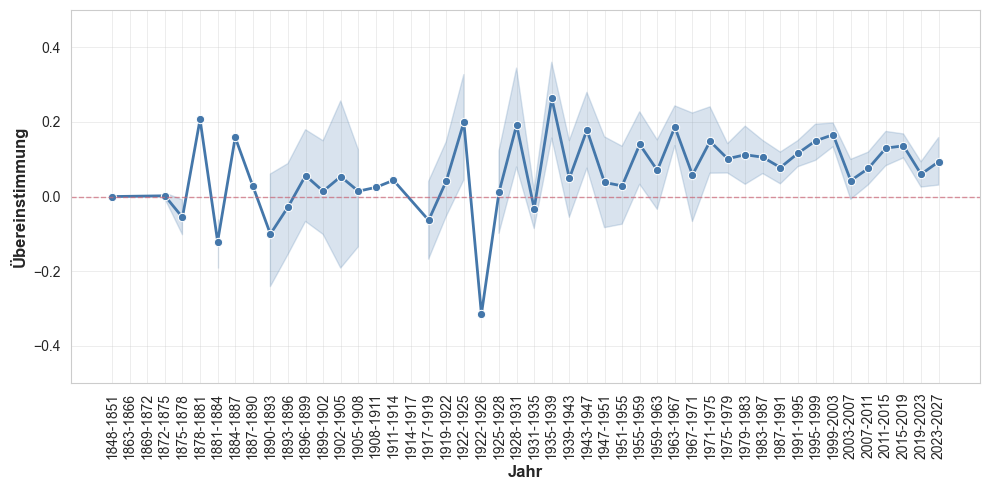

In [38]:
liniendiagramm(df, x="legisjahr", y="zustimmung_br-pos", xlabel="Jahr", ylabel="Übereinstimmung", rotation=90, errorbar=True, hline=0)

#### Liniendiagramm: BV

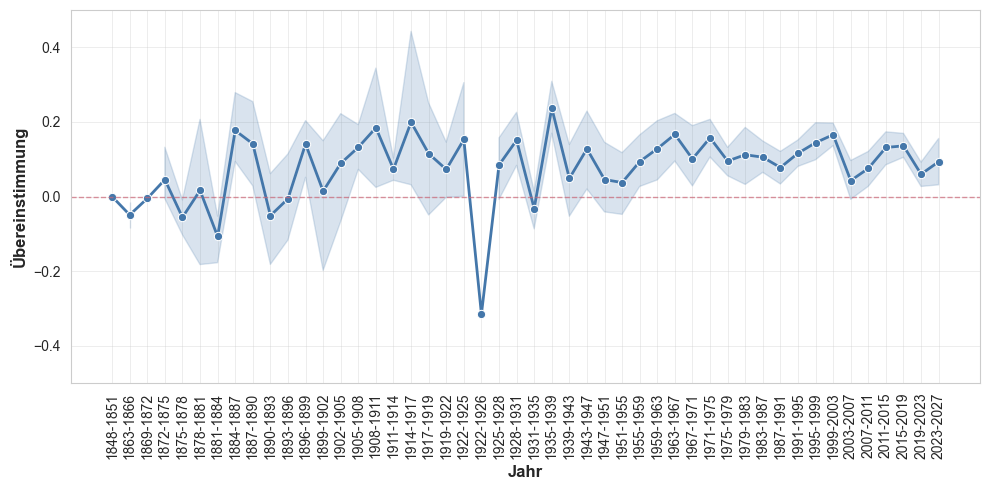

In [39]:
liniendiagramm(df, x="legisjahr", y="zustimmung_bv-pos", xlabel="Jahr", ylabel="Übereinstimmung", rotation=90, errorbar=True,  hline=0)

/Users/charlotteschwegler/Desktop/Repos/Demokratie Challenge/notebooks/visualisierungen.py:8: UserWarning: The palette list has more values (6) than needed (2), which may not be intended.
  import pandas as pd


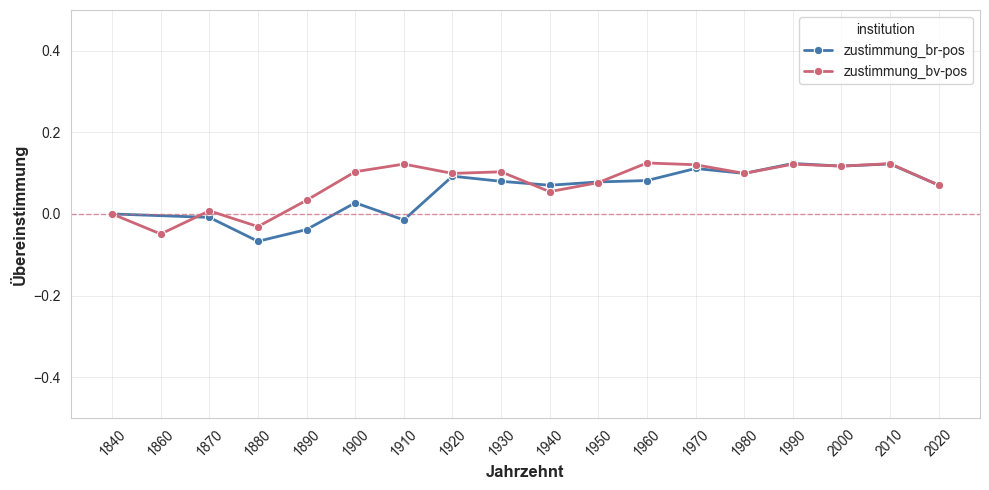

In [40]:
bund = df[['jahrzehnt', 'zustimmung_br-pos', 'zustimmung_bv-pos']].melt(
    id_vars='jahrzehnt', var_name='institution', value_name='zustimmung')

liniendiagramm(bund, x="jahrzehnt", y="zustimmung", hue="institution",
               xlabel="Jahrzehnt", ylabel="Übereinstimmung", rotation=45,  hline=0)

#### Alle Institutionen

/Users/charlotteschwegler/Desktop/Repos/Demokratie Challenge/notebooks/visualisierungen.py:8: UserWarning: The palette list has more values (6) than needed (3), which may not be intended.
  import pandas as pd


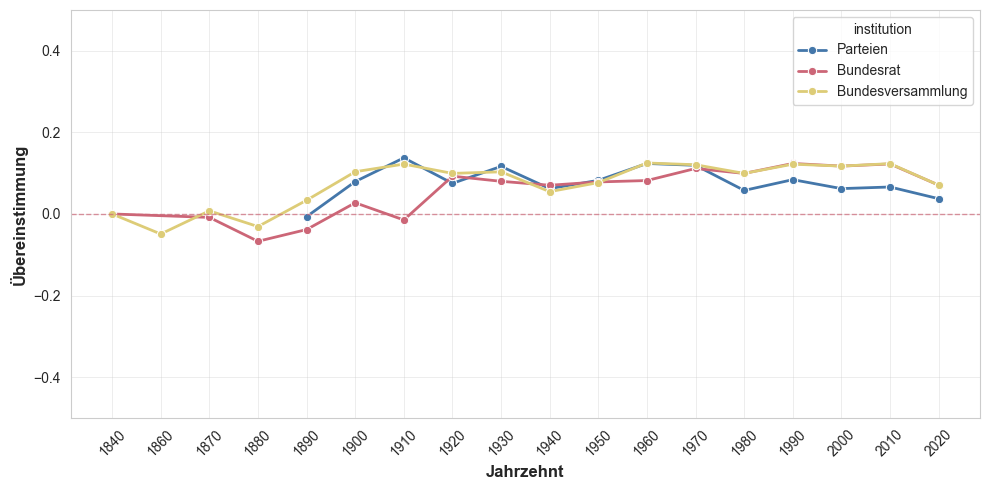

In [41]:
frames = []
for name, cols in institutionen.items():
    mittel = df.groupby('jahrzehnt')[cols].mean().mean(axis=1).reset_index(name='zustimmung')
    mittel['institution'] = name
    frames.append(mittel)

df_inst = pd.concat(frames, ignore_index=True)

liniendiagramm(df_inst, x="jahrzehnt", y="zustimmung", hue="institution",
               xlabel="Jahrzehnt", ylabel="Übereinstimmung", rotation=45, hline=0)

Dieser Plot ist spannend. Ab den 1970er Jahren ist die Zustimmung der Bevölkerung mit Bund/Parlament sehr viel höher als mit den Parteien. Ausserdem BV und BR sehr deckungsgleich ab 1980?
Gab es einen instiutionellen Wandel der diese Entwicklung erklärt? Einfluss Frauenstimmrecht? Später Aufschwung SVP? Uniforme Position
Einführung Zauberformel 1959 --> Erhöhte Einigkeit zwischen BV und BR

### Boxplot: BR Rechtsform


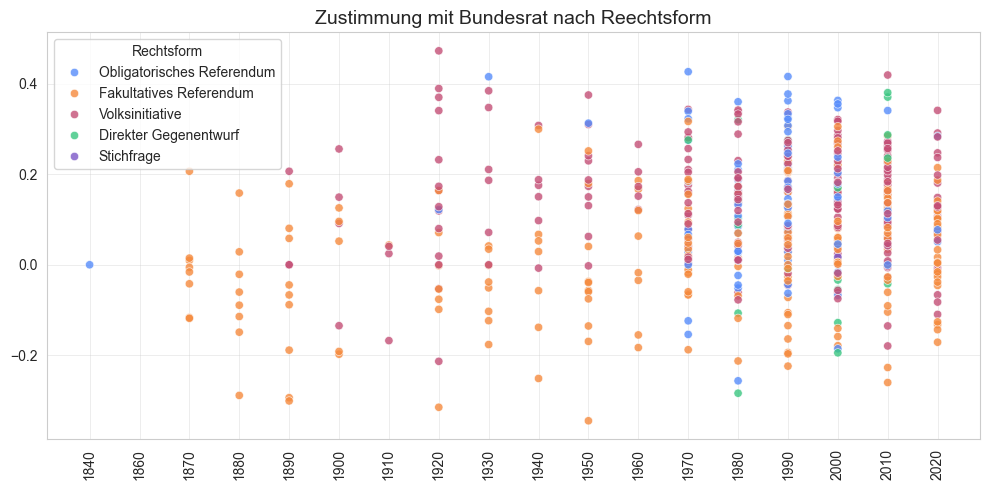

In [42]:
scatterplot(df, x="jahrzehnt", y="zustimmung_br-pos", size=None, titel="Zustimmung mit Bundesrat nach Reechtsform", xlabel="", ylabel="", legendentitel='Rechtsform',
               sizes=(20,800), alpha=0.8, hue='rechtsform_name', figsize=(10,5), rotation=90)

## Rechtsform/

In [43]:
### BR

/Users/charlotteschwegler/Desktop/Repos/Demokratie Challenge/notebooks/visualisierungen.py:8: UserWarning: The palette list has more values (6) than needed (5), which may not be intended.
  import pandas as pd


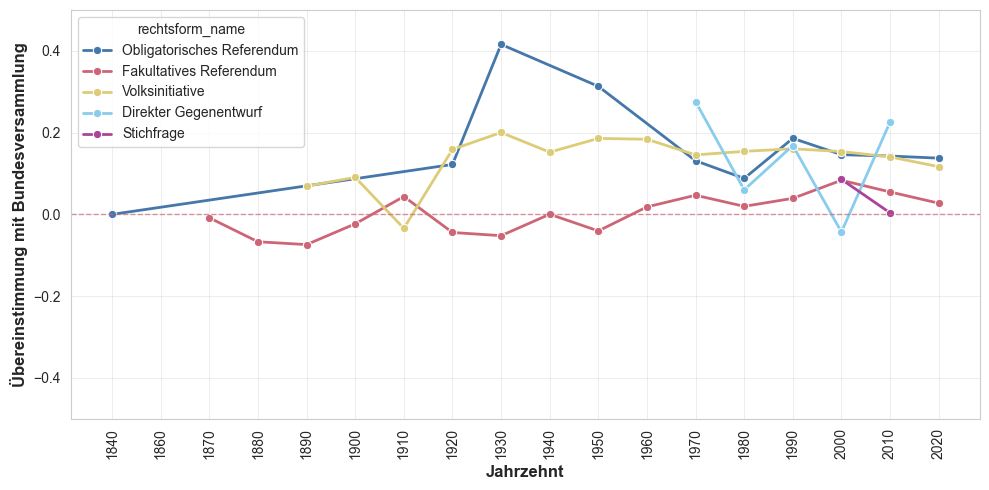

In [44]:
liniendiagramm(df, x="jahrzehnt", y="zustimmung_br-pos",
               xlabel="Jahrzehnt", ylabel="Übereinstimmung mit Bundesversammlung", rotation=90, hue="rechtsform_name", errorbar=False, hline=0)

In [45]:
### BV

/Users/charlotteschwegler/Desktop/Repos/Demokratie Challenge/notebooks/visualisierungen.py:8: UserWarning: The palette list has more values (6) than needed (5), which may not be intended.
  import pandas as pd


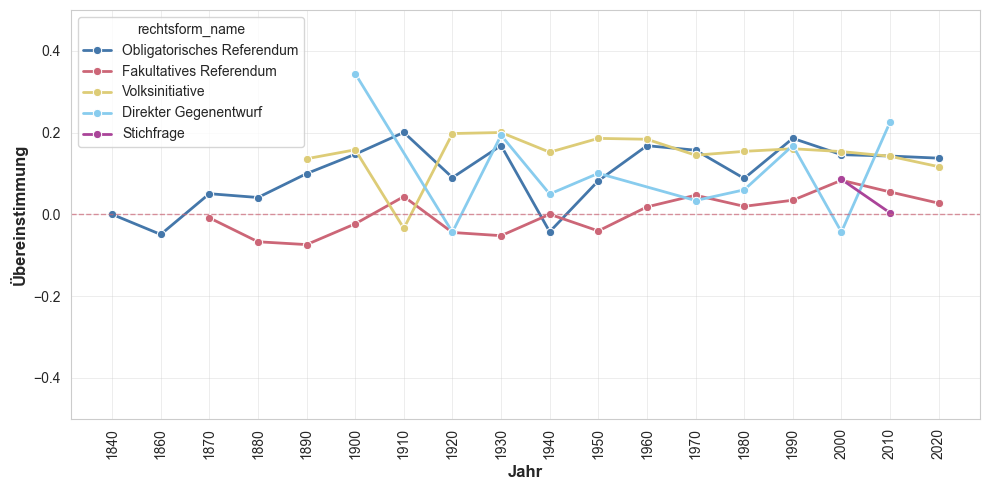

In [46]:
liniendiagramm(df, x="jahrzehnt", y="zustimmung_bv-pos",
               xlabel="Jahr", ylabel="Übereinstimmung", rotation=90, hue="rechtsform_name", errorbar=None,  hline=0)

###Parteien

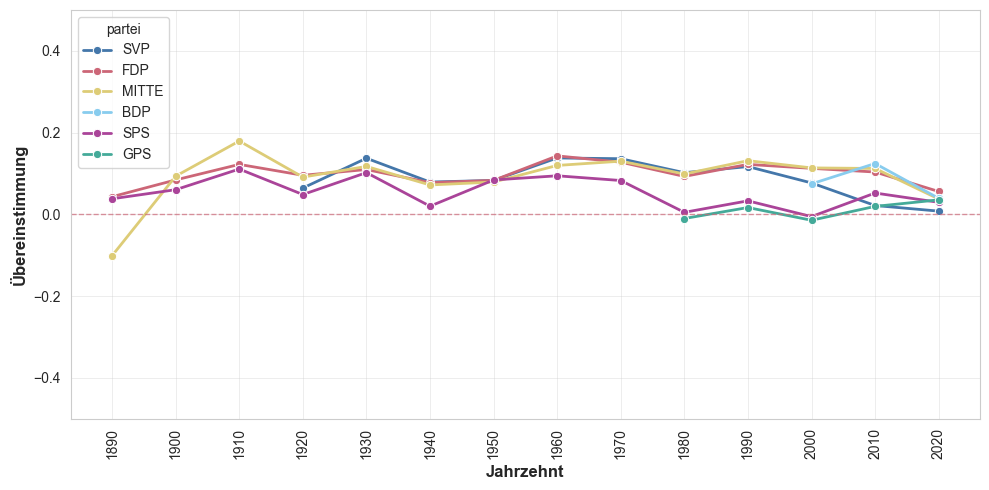

In [47]:
partei_cols = ["zustimmung_p-svp", "zustimmung_p-fdp", "zustimmung_p-mitte","zustimmung_p-bdp", "zustimmung_p-sps", "zustimmung_p-gps"]

df_long = df[["jahrzehnt"] + partei_cols].melt(
    id_vars="jahrzehnt", var_name="partei", value_name="zustimmung")
df_long['partei'] = df_long['partei'].str.replace('zustimmung_p-', '').str.upper()

liniendiagramm(df_long, x="jahrzehnt", y="zustimmung", hue="partei",
               xlabel="Jahrzehnt", ylabel="Übereinstimmung", rotation=90, hline=0)
